In [2]:
# Arreglos y matrices brutos
import numpy
# Series y Tablas (DataFrame) decorados
import pandas

# Gráficas y configuraciones brutas
from matplotlib import pyplot
# Gráficas modernas y decoradas
import seaborn

In [ ]:
# Leer la tabla de datos de pandas desde el CSV (Comma-Separated-Values)
titanic = pandas.read_csv("../conjuntos/titanic.csv")

titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [8]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


> Selección de columnas

In [ ]:
titanic2 = titanic[["Sex", "Age", "Pclass", "SibSp", "Parch", 
                    "Fare", "Cabin", "Embarked", "Survived"]].copy()

titanic2

,Sex,Age,Pclass,SibSp,Parch,Fare,Cabin,Embarked,Survived
0,male,22.0,3,1,0,7.2500,NaN,S,0
1,female,38.0,1,1,0,71.2833,C85,C,1
2,female,26.0,3,0,0,7.9250,NaN,S,1
3,female,35.0,1,1,0,53.1000,C123,S,1
4,male,35.0,3,0,0,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...
886,male,27.0,2,0,0,13.0000,NaN,S,0
887,female,19.0,1,0,0,30.0000,B42,S,1
888,female,NaN,3,1,2,23.4500,NaN,S,0
889,male,26.0,1,0,0,30.0000,C148,C,1


In [78]:
titanic2.sample(30, random_state=123)

,Sex,Age,Pclass,SibSp,Parch,Fare,Cabin,Embarked,Survived
172,female,1.00,3,1,1,11.1333,NaN,S,1
524,male,NaN,3,0,0,7.2292,NaN,C,0
452,male,30.00,1,0,0,27.7500,C111,C,0
170,male,61.00,1,0,0,33.5000,B19,S,0
620,male,27.00,3,1,0,14.4542,NaN,C,0
397,male,46.00,2,0,0,26.0000,NaN,S,0
161,female,40.00,2,0,0,15.7500,NaN,S,1
41,female,27.00,2,1,0,21.0000,NaN,S,0
702,female,18.00,3,0,1,14.4542,NaN,C,0
567,female,29.00,3,0,4,21.0750,NaN,S,0


In [79]:
titanic2["Sex"].describe()

count      891
unique       2
top       male
freq       577
Name: Sex, dtype: object

In [80]:
titanic2["Sex"].value_counts() # Soportes

Sex
male      577
female    314
Name: count, dtype: int64

In [81]:
titanic2["Sex"].value_counts(normalize=True) # Proporciones

Sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64

<Axes: xlabel='Sex', ylabel='proportion'>

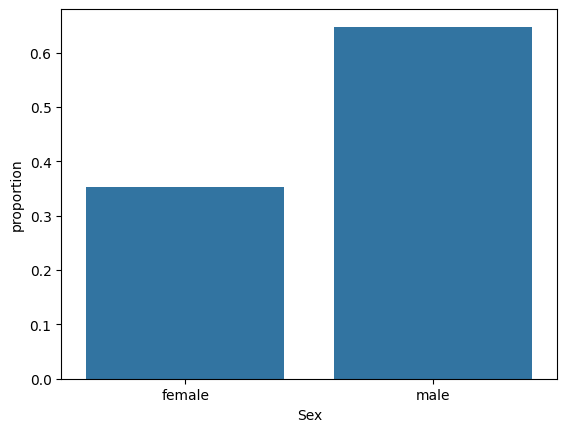

In [82]:
seaborn.barplot(
    titanic2["Sex"].value_counts(normalize=True).sort_values()
)

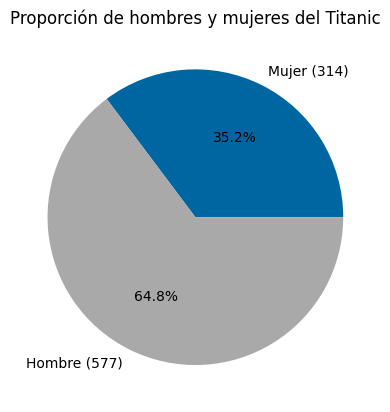

In [83]:
conteos = titanic2["Sex"].value_counts().sort_values() # Conteos ordenados
mapa = {
    "male": "Hombre",
    "female": "Mujer"
}
etiquetas = conteos.index.map(lambda indice: f"{mapa[indice]} ({conteos[indice]})") # Etiquetas o índices de cada conteo
colores = conteos.index.map({
    "male": "darkgray",
    "female": "#0066a1"
})

pyplot.pie(conteos, labels=etiquetas, autopct="%.1f%%", colors=colores) # conteos y etiquetas
pyplot.title("Proporción de hombres y mujeres del Titanic")
pyplot.savefig("sex_pie.png")
pyplot.show()

In [84]:
titanic2["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: xlabel='Age', ylabel='Density'>

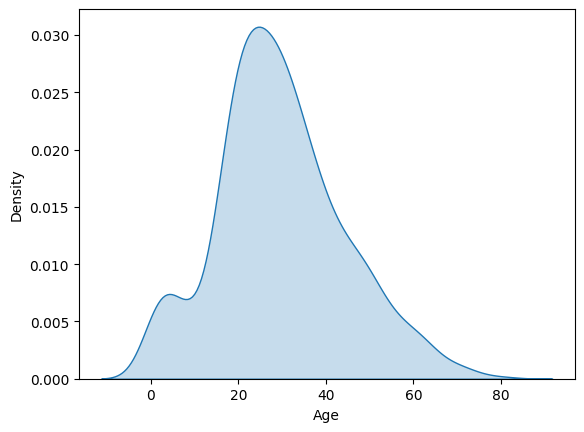

In [85]:
seaborn.kdeplot(x=titanic2["Age"], fill=True)

<Axes: xlabel='Age'>

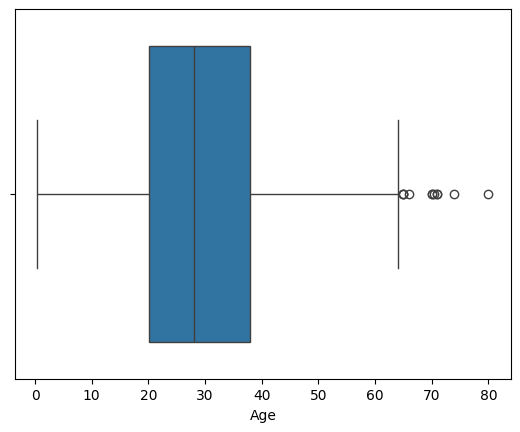

In [86]:
seaborn.boxplot(x=titanic2["Age"])

<Axes: xlabel='Age'>

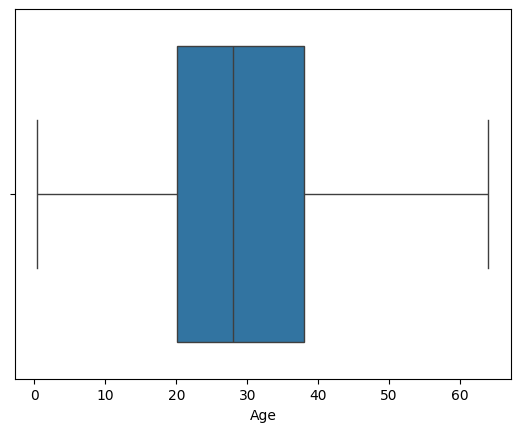

In [87]:
seaborn.boxplot(x=titanic2["Age"], showfliers=False)

In [88]:
filtro = titanic["Age"] < 1
titanic[filtro][["Name", "Sex", "Age"]]

,Name,Sex,Age
78,"Caldwell, Master. Alden Gates",male,0.83
305,"Allison, Master. Hudson Trevor",male,0.92
469,"Baclini, Miss. Helene Barbara",female,0.75
644,"Baclini, Miss. Eugenie",female,0.75
755,"Hamalainen, Master. Viljo",male,0.67
803,"Thomas, Master. Assad Alexander",male,0.42
831,"Richards, Master. George Sibley",male,0.83


In [89]:
filtro = titanic["Age"] > 60
titanic[filtro][["Name", "Sex", "Age"]]

,Name,Sex,Age
33,"Wheadon, Mr. Edward H",male,66.0
54,"Ostby, Mr. Engelhart Cornelius",male,65.0
96,"Goldschmidt, Mr. George B",male,71.0
116,"Connors, Mr. Patrick",male,70.5
170,"Van der hoef, Mr. Wyckoff",male,61.0
252,"Stead, Mr. William Thomas",male,62.0
275,"Andrews, Miss. Kornelia Theodosia",female,63.0
280,"Duane, Mr. Frank",male,65.0
326,"Nysveen, Mr. Johan Hansen",male,61.0
438,"Fortune, Mr. Mark",male,64.0


In [90]:
filtro = titanic2["Age"] < 1

titanic2.loc[filtro, ["Age"]] = numpy.nan

titanic2[filtro]

,Sex,Age,Pclass,SibSp,Parch,Fare,Cabin,Embarked,Survived
78,male,NaN,2,0,2,29.0000,NaN,S,1
305,male,NaN,1,1,2,151.5500,C22 C26,S,1
469,female,NaN,3,2,1,19.2583,NaN,C,1
644,female,NaN,3,2,1,19.2583,NaN,C,1
755,male,NaN,2,1,1,14.5000,NaN,S,1
803,male,NaN,3,0,1,8.5167,NaN,C,1
831,male,NaN,2,1,1,18.7500,NaN,S,1


In [108]:
pandas.DataFrame({
    "Edades no nulas": [titanic2["Age"].count()],
    "Edades nulas": [titanic2["Age"].isna().sum()],
    "Edades nulas %": [100 * titanic2["Age"].isna().sum() / len(titanic2)],
}, index=["Valor"]).round(0).astype(int)

,Edades no nulas,Edades nulas,Edades nulas %
Valor,707,184,21


In [115]:
# La columna Pclass2 es igual a la columna Pclass
# pero reconvirtiendo (mapeando / transformado)
# cada valor, dado un diccionario o mapa
# de transformación
titanic2["Pclass2"] = titanic2["Pclass"].map({
    1: "1ra",
    2: "2da",
    3: "3ra",
})

titanic2

,Sex,Age,Pclass,SibSp,Parch,Fare,Cabin,Embarked,Survived,Pclass2
0,male,22.0,3,1,0,7.2500,NaN,S,0,3ra
1,female,38.0,1,1,0,71.2833,C85,C,1,1ra
2,female,26.0,3,0,0,7.9250,NaN,S,1,3ra
3,female,35.0,1,1,0,53.1000,C123,S,1,1ra
4,male,35.0,3,0,0,8.0500,NaN,S,0,3ra
...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,2,0,0,13.0000,NaN,S,0,2da
887,female,19.0,1,0,0,30.0000,B42,S,1,1ra
888,female,NaN,3,1,2,23.4500,NaN,S,0,3ra
889,male,26.0,1,0,0,30.0000,C148,C,1,1ra


In [116]:
titanic2["Pclass2"].describe()

count     891
unique      3
top       3ra
freq      491
Name: Pclass2, dtype: object

In [117]:
titanic2["Pclass2"].value_counts()

Pclass2
3ra    491
1ra    216
2da    184
Name: count, dtype: int64

In [119]:
titanic2["Pclass2"].value_counts(normalize=True)

Pclass2
3ra    0.551066
1ra    0.242424
2da    0.206510
Name: proportion, dtype: float64

<Axes: xlabel='Pclass2', ylabel='count'>

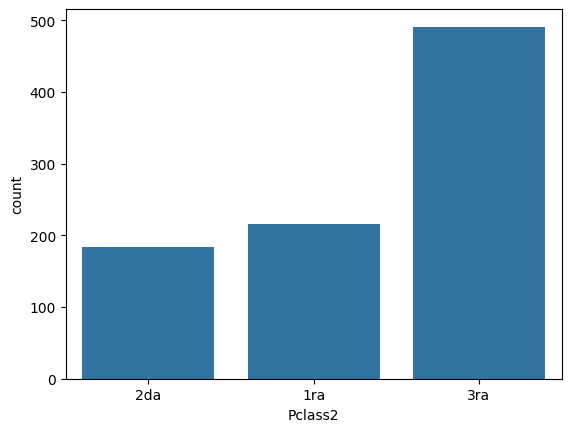

In [121]:
seaborn.barplot(
    titanic2["Pclass2"].value_counts().sort_values()
)

In [122]:
titanic2["Family"] = titanic2["SibSp"] + titanic2["Parch"]

titanic2

,Sex,Age,Pclass,SibSp,Parch,Fare,Cabin,Embarked,Survived,Pclass2,Family
0,male,22.0,3,1,0,7.2500,NaN,S,0,3ra,1
1,female,38.0,1,1,0,71.2833,C85,C,1,1ra,1
2,female,26.0,3,0,0,7.9250,NaN,S,1,3ra,0
3,female,35.0,1,1,0,53.1000,C123,S,1,1ra,1
4,male,35.0,3,0,0,8.0500,NaN,S,0,3ra,0
...,...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,2,0,0,13.0000,NaN,S,0,2da,0
887,female,19.0,1,0,0,30.0000,B42,S,1,1ra,0
888,female,NaN,3,1,2,23.4500,NaN,S,0,3ra,3
889,male,26.0,1,0,0,30.0000,C148,C,1,1ra,0


In [124]:
def family_to_cat(family):
    if family == 0:
        return "single"
    elif family == 1:
        return "couple"
    else:
        return "family"

titanic2["Family2"] = titanic2["Family"].map(family_to_cat)

titanic2

,Sex,Age,Pclass,SibSp,Parch,Fare,Cabin,Embarked,Survived,Pclass2,Family,Family2
0,male,22.0,3,1,0,7.2500,NaN,S,0,3ra,1,couple
1,female,38.0,1,1,0,71.2833,C85,C,1,1ra,1,couple
2,female,26.0,3,0,0,7.9250,NaN,S,1,3ra,0,single
3,female,35.0,1,1,0,53.1000,C123,S,1,1ra,1,couple
4,male,35.0,3,0,0,8.0500,NaN,S,0,3ra,0,single
...,...,...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,2,0,0,13.0000,NaN,S,0,2da,0,single
887,female,19.0,1,0,0,30.0000,B42,S,1,1ra,0,single
888,female,NaN,3,1,2,23.4500,NaN,S,0,3ra,3,family
889,male,26.0,1,0,0,30.0000,C148,C,1,1ra,0,single


In [128]:
titanic2["Family2"].describe()

count        891
unique         3
top       single
freq         537
Name: Family2, dtype: object

In [129]:
titanic2["Family2"].value_counts()

Family2
single    537
family    193
couple    161
Name: count, dtype: int64

In [130]:
titanic2["Family2"].value_counts(normalize=True)

Family2
single    0.602694
family    0.216611
couple    0.180696
Name: proportion, dtype: float64

<Axes: xlabel='Family2', ylabel='count'>

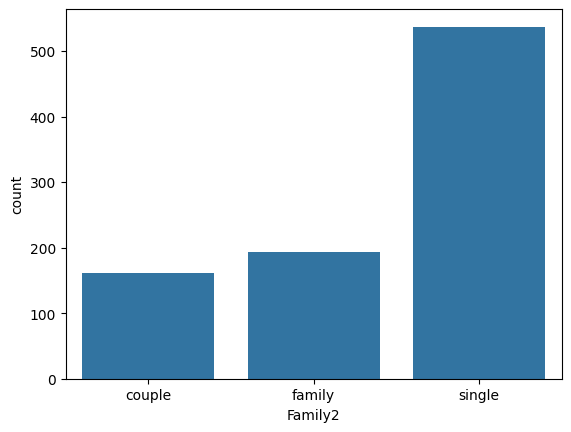

In [131]:
seaborn.barplot(
    titanic2["Family2"].value_counts().sort_values()
)

<Axes: ylabel='Family2'>

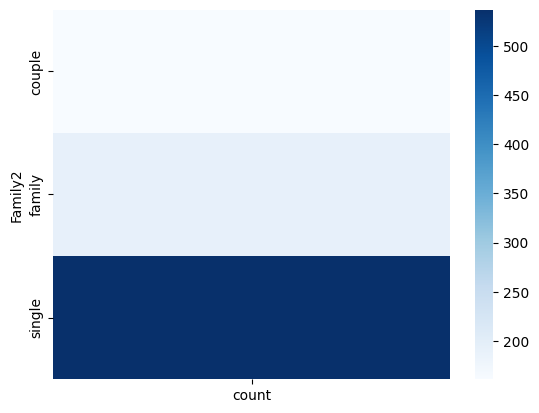

In [144]:
seaborn.heatmap(
    pandas.DataFrame(titanic2["Family2"].value_counts().sort_values()),
    cmap="Blues"
)

In [145]:
titanic2["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: xlabel='Fare', ylabel='Density'>

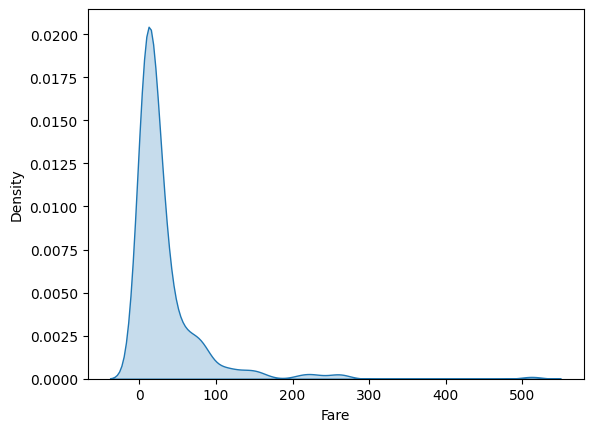

In [147]:
seaborn.kdeplot(titanic2["Fare"], fill=True)

<Axes: ylabel='Fare'>

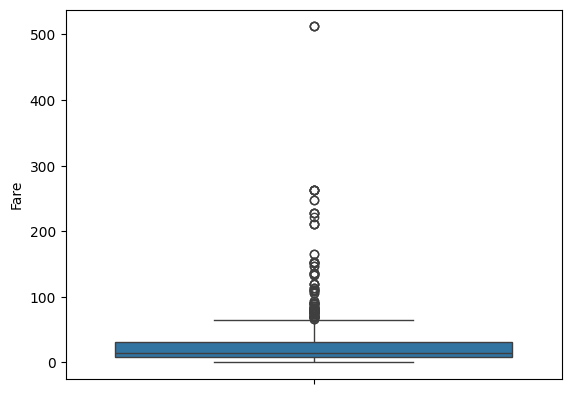

In [149]:
seaborn.boxplot(y=titanic2["Fare"])

<Axes: ylabel='Fare'>

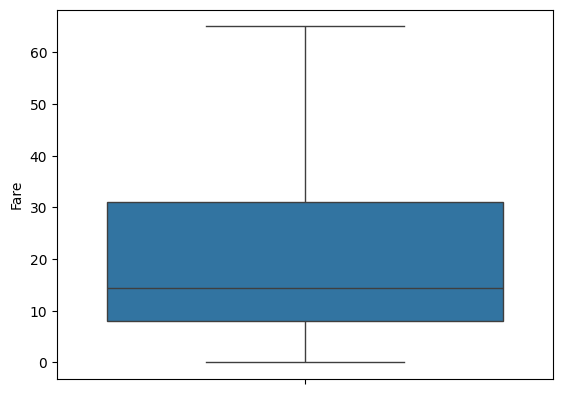

In [150]:
seaborn.boxplot(y=titanic2["Fare"], showfliers=False)

In [153]:
titanic2["Fare2"] = titanic2["Fare"].apply(lambda fare: numpy.log1p(titanic2["Fare2"].min() + fare))

titanic2

,Sex,Age,Pclass,SibSp,Parch,Fare,Cabin,Embarked,Survived,Pclass2,Family,Family2,Fare2
0,male,22.0,3,1,0,7.2500,NaN,S,0,3ra,1,couple,2.110213
1,female,38.0,1,1,0,71.2833,C85,C,1,1ra,1,couple,4.280593
2,female,26.0,3,0,0,7.9250,NaN,S,1,3ra,0,single,2.188856
3,female,35.0,1,1,0,53.1000,C123,S,1,1ra,1,couple,3.990834
4,male,35.0,3,0,0,8.0500,NaN,S,0,3ra,0,single,2.202765
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,2,0,0,13.0000,NaN,S,0,2da,0,single,2.639057
887,female,19.0,1,0,0,30.0000,B42,S,1,1ra,0,single,3.433987
888,female,NaN,3,1,2,23.4500,NaN,S,0,3ra,3,family,3.196630
889,male,26.0,1,0,0,30.0000,C148,C,1,1ra,0,single,3.433987


<Axes: xlabel='Fare2', ylabel='Density'>

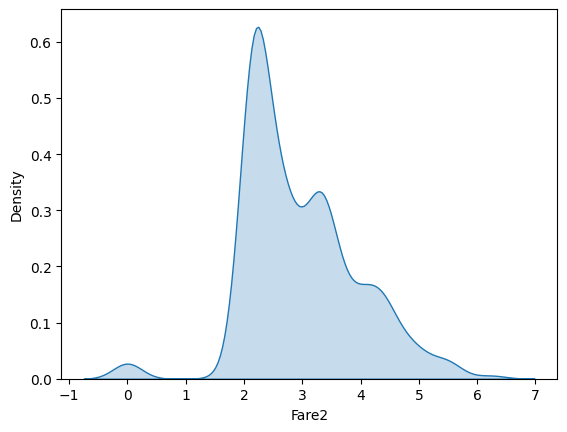

In [155]:
seaborn.kdeplot(titanic2["Fare2"], fill=True)

In [160]:
titanic2["Cabin2"] = (~titanic2["Cabin"].isna()).map({
    True: "yes",
    False: "no"
}) # no (isna - Es nula) / Si tiene cabina

titanic2

,Sex,Age,Pclass,SibSp,Parch,Fare,Cabin,Embarked,Survived,Pclass2,Family,Family2,Fare2,Cabin2
0,male,22.0,3,1,0,7.2500,NaN,S,0,3ra,1,couple,2.110213,no
1,female,38.0,1,1,0,71.2833,C85,C,1,1ra,1,couple,4.280593,yes
2,female,26.0,3,0,0,7.9250,NaN,S,1,3ra,0,single,2.188856,no
3,female,35.0,1,1,0,53.1000,C123,S,1,1ra,1,couple,3.990834,yes
4,male,35.0,3,0,0,8.0500,NaN,S,0,3ra,0,single,2.202765,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,2,0,0,13.0000,NaN,S,0,2da,0,single,2.639057,no
887,female,19.0,1,0,0,30.0000,B42,S,1,1ra,0,single,3.433987,yes
888,female,NaN,3,1,2,23.4500,NaN,S,0,3ra,3,family,3.196630,no
889,male,26.0,1,0,0,30.0000,C148,C,1,1ra,0,single,3.433987,yes


In [165]:
titanic2["Embarked2"] = titanic2["Embarked"].fillna("X")

filtro = titanic2["Embarked2"] == "X"
titanic[filtro]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [166]:
titanic2["Embarked2"].describe()

count     891
unique      4
top         S
freq      644
Name: Embarked2, dtype: object

In [167]:
titanic2["Embarked2"].value_counts()

Embarked2
S    644
C    168
Q     77
X      2
Name: count, dtype: int64

In [168]:
titanic2["Embarked2"].value_counts(normalize=True)

Embarked2
S    0.722783
C    0.188552
Q    0.086420
X    0.002245
Name: proportion, dtype: float64

<Axes: xlabel='Embarked2', ylabel='count'>

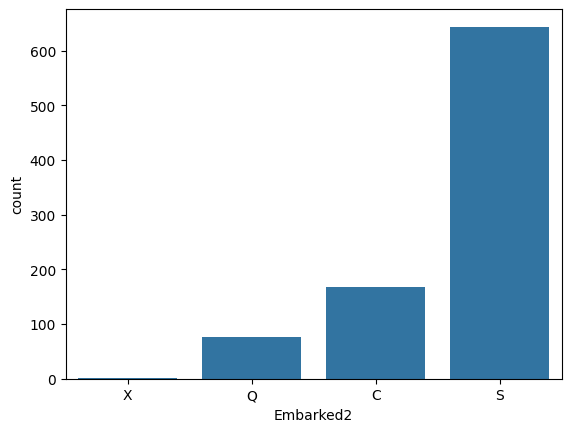

In [169]:
seaborn.barplot(
    titanic2["Embarked2"].value_counts().sort_values()
)

In [172]:
titanic2["Survived2"] = titanic2["Survived"].map({
    0: "no",
    1: "yes"
})

titanic2

,Sex,Age,Pclass,SibSp,Parch,Fare,Cabin,Embarked,Survived,Pclass2,Family,Family2,Fare2,Cabin2,Embarked2,Survived2
0,male,22.0,3,1,0,7.2500,NaN,S,0,3ra,1,couple,2.110213,no,S,no
1,female,38.0,1,1,0,71.2833,C85,C,1,1ra,1,couple,4.280593,yes,C,yes
2,female,26.0,3,0,0,7.9250,NaN,S,1,3ra,0,single,2.188856,no,S,yes
3,female,35.0,1,1,0,53.1000,C123,S,1,1ra,1,couple,3.990834,yes,S,yes
4,male,35.0,3,0,0,8.0500,NaN,S,0,3ra,0,single,2.202765,no,S,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,2,0,0,13.0000,NaN,S,0,2da,0,single,2.639057,no,S,no
887,female,19.0,1,0,0,30.0000,B42,S,1,1ra,0,single,3.433987,yes,S,yes
888,female,NaN,3,1,2,23.4500,NaN,S,0,3ra,3,family,3.196630,no,S,no
889,male,26.0,1,0,0,30.0000,C148,C,1,1ra,0,single,3.433987,yes,C,yes


In [173]:
titanic2["Survived2"].describe()

count     891
unique      2
top        no
freq      549
Name: Survived2, dtype: object

In [174]:
titanic2["Survived2"].value_counts()

Survived2
no     549
yes    342
Name: count, dtype: int64

In [176]:
titanic2["Survived2"].value_counts(normalize=True)

Survived2
no     0.616162
yes    0.383838
Name: proportion, dtype: float64

<Axes: xlabel='Survived2', ylabel='count'>

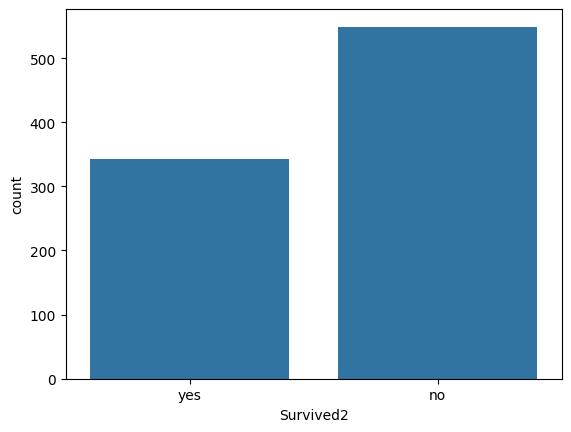

In [177]:
seaborn.barplot(
    titanic2["Survived2"].value_counts().sort_values()
)

In [183]:
titanic3 = titanic2[["Sex", "Age", "Pclass2", "Family", "Family2", "Fare2", "Cabin2", "Embarked2", "Survived2"]]

titanic3.to_csv("../conjuntos/titanic3.csv", index=False)

titanic3

,Sex,Age,Pclass2,Family,Family2,Fare2,Cabin2,Embarked2,Survived2
0,male,22.0,3ra,1,couple,2.110213,no,S,no
1,female,38.0,1ra,1,couple,4.280593,yes,C,yes
2,female,26.0,3ra,0,single,2.188856,no,S,yes
3,female,35.0,1ra,1,couple,3.990834,yes,S,yes
4,male,35.0,3ra,0,single,2.202765,no,S,no
...,...,...,...,...,...,...,...,...,...
886,male,27.0,2da,0,single,2.639057,no,S,no
887,female,19.0,1ra,0,single,3.433987,yes,S,yes
888,female,NaN,3ra,3,family,3.196630,no,S,no
889,male,26.0,1ra,0,single,3.433987,yes,C,yes
